# Vulnerability mapping

In [1]:
%load_ext jupyter_black
%load_ext autoreload
%autoreload 2

In [15]:
import geopandas as gpd
import pandas as pd
import matplotlib.pyplot as plt

from src.datasources import ocha, codab, hydrosheds
from src.constants import ADM3_AOI_PCODES

In [3]:
adm3 = codab.load_codab(admin_level=3, aoi_only=True)
adm1 = codab.load_codab(admin_level=1, aoi_only=True)

In [4]:
river = hydrosheds.load_niger_river()
river_aoi = gpd.sjoin(river, adm3, how="inner", predicate="intersects")

<Axes: >

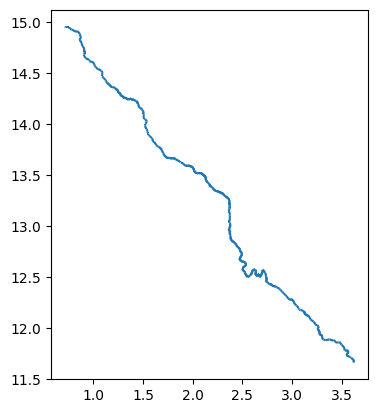

In [5]:
river_aoi.plot()

In [6]:
adm3[adm3["ADM3_FR"].str.startswith("Ay")]

,ADM3_FR,ADM3_PCODE,ADM2_FR,ADM2_PCODE,ADM1_FR,ADM1_PCODE,ADM0_FR,ADM0_PCODE,DATE,VALIDON,VALIDTO,geometry
163,Ayerou,NE006002001,Ayerou,NE006002,Tillabéri,NE006,Niger (the),NE,2023-06-21,2023-07-25,NaN,"POLYGON ((0.70316 14.94583, 0.70787 14.94746, ..."


In [7]:
filepath = ocha.COMMUNES_RAW_PATH.parent / "Book1_fromDaniel.xlsx"
df = pd.read_excel(filepath, skiprows=[0])
df = df.iloc[:-1]
df["Commune"] = df["Commune"].replace("Ayorou", "Ayerou")
df = df.merge(
    adm3.rename(columns={"ADM3_FR": "Commune"})[["Commune", "ADM3_PCODE"]]
)
int_cols = ["Vulnérables"]
df[int_cols] = df[int_cols].astype(int)
df

,N°,Région,Département,Commune,Degré de vulnérabilité,Acces sécuritaire,Accès physique,Acces,population,Vulnérables,...,PNUD,OMS,UNFPA,HCR,OIM,SAP,CRN,DMN,Totalt,ADM3_PCODE
0,1,DOSSO,Boboye,Fabidji,Moyennement,Accessible,Accessible,3.0,61826,42078,...,1.0,1.0,1.0,1.0,NaN,1.0,NaN,1.0,11.0,NE003001002
1,2,DOSSO,Boboye,Fakara,Faiblement,Accessible,Accessible,3.0,29706,0,...,1.0,1.0,1.0,1.0,NaN,1.0,NaN,1.0,11.0,NE003001003
2,3,DOSSO,Dosso,Sambéra,Faiblement,Accessible,Accessible,3.0,79126,0,...,1.0,1.0,1.0,1.0,NaN,1.0,NaN,1.0,11.0,NE003004008
3,4,DOSSO,Falmey,Falmey,Extrêmement,Accessible,Accessible,3.0,116957,34511,...,1.0,1.0,1.0,1.0,NaN,1.0,NaN,1.0,11.0,NE003005001
4,5,DOSSO,Falmey,Guilladjé,Moyennement,Accessible,Accessible,3.0,43842,17113,...,1.0,1.0,1.0,1.0,NaN,1.0,NaN,1.0,11.0,NE003005002
5,6,DOSSO,Gaya,Gaya,Faiblement,Accessible,Accessible,3.0,99362,0,...,1.0,1.0,1.0,1.0,NaN,1.0,NaN,1.0,11.0,NE003006003
6,7,DOSSO,Gaya,Tanda,Faiblement,Accessible,Difficultés,2.0,77810,0,...,1.0,1.0,1.0,1.0,NaN,1.0,NaN,1.0,10.0,NE003006004
7,8,DOSSO,Gaya,Tounouga,Faiblement,Accessible,Difficultés,2.0,66713,0,...,1.0,1.0,1.0,1.0,NaN,1.0,NaN,1.0,10.0,NE003006005
8,9,TILLABERI,Ayerou,Ayerou,Moyennement,Difficultés,Accessible,2.0,51758,37760,...,0.0,1.0,1.0,1.0,1.0,1.0,1.0,1.0,10.0,NE006002001
9,10,TILLABERI,Gothèye,Dargol,Moyennement,Difficultés,Accessible,2.0,228125,81411,...,0.0,1.0,0.0,0.0,0.0,1.0,1.0,1.0,9.0,NE006007001


(-0.05552903579999999, 4.8236206858, 11.462306522549298, 15.912396359783367)

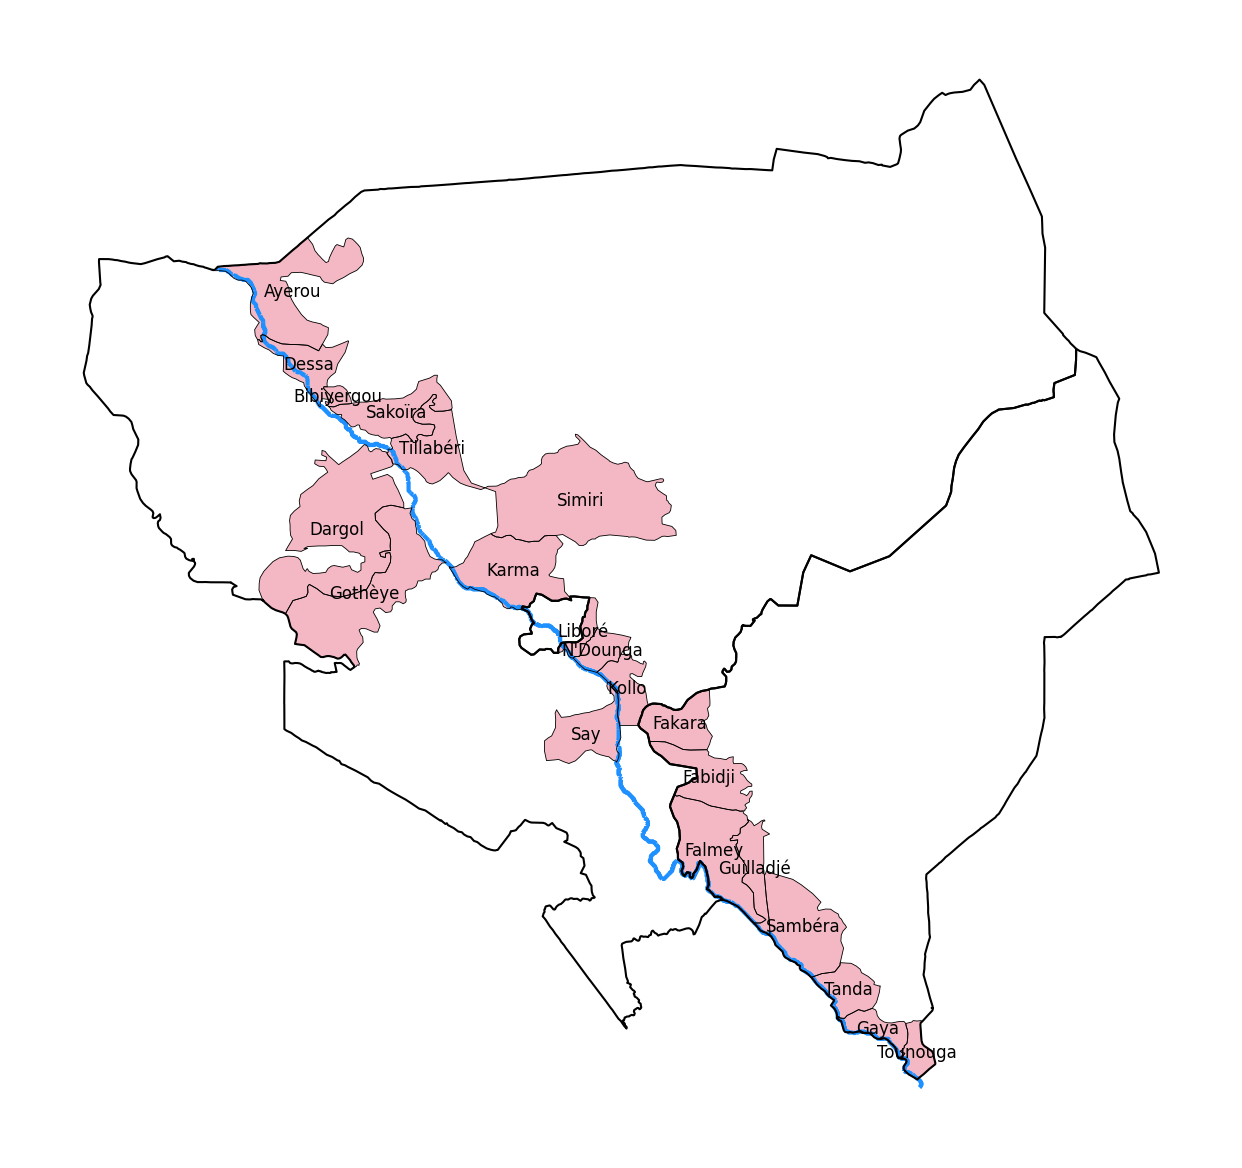

In [8]:
gdf_plot = adm3.merge(df)

fig, ax = plt.subplots(dpi=300)
river_aoi.plot(ax=ax, color="dodgerblue", linewidth=1)
adm1.boundary.plot(ax=ax, linewidth=0.5, color="k")
gdf_plot.plot(ax=ax, color="crimson", alpha=0.3)
gdf_plot.boundary.plot(ax=ax, linewidth=0.2, color="k")

for idx, row in gdf_plot.iterrows():
    plt.annotate(
        text=row["Commune"],
        xy=(row["geometry"].centroid.x, row["geometry"].centroid.y),
        horizontalalignment="center",
        verticalalignment="center",
        fontsize=4,
    )
ax.axis("off")

(-0.05552903579999999, 4.8236206858, 11.462306522549298, 15.912396359783367)

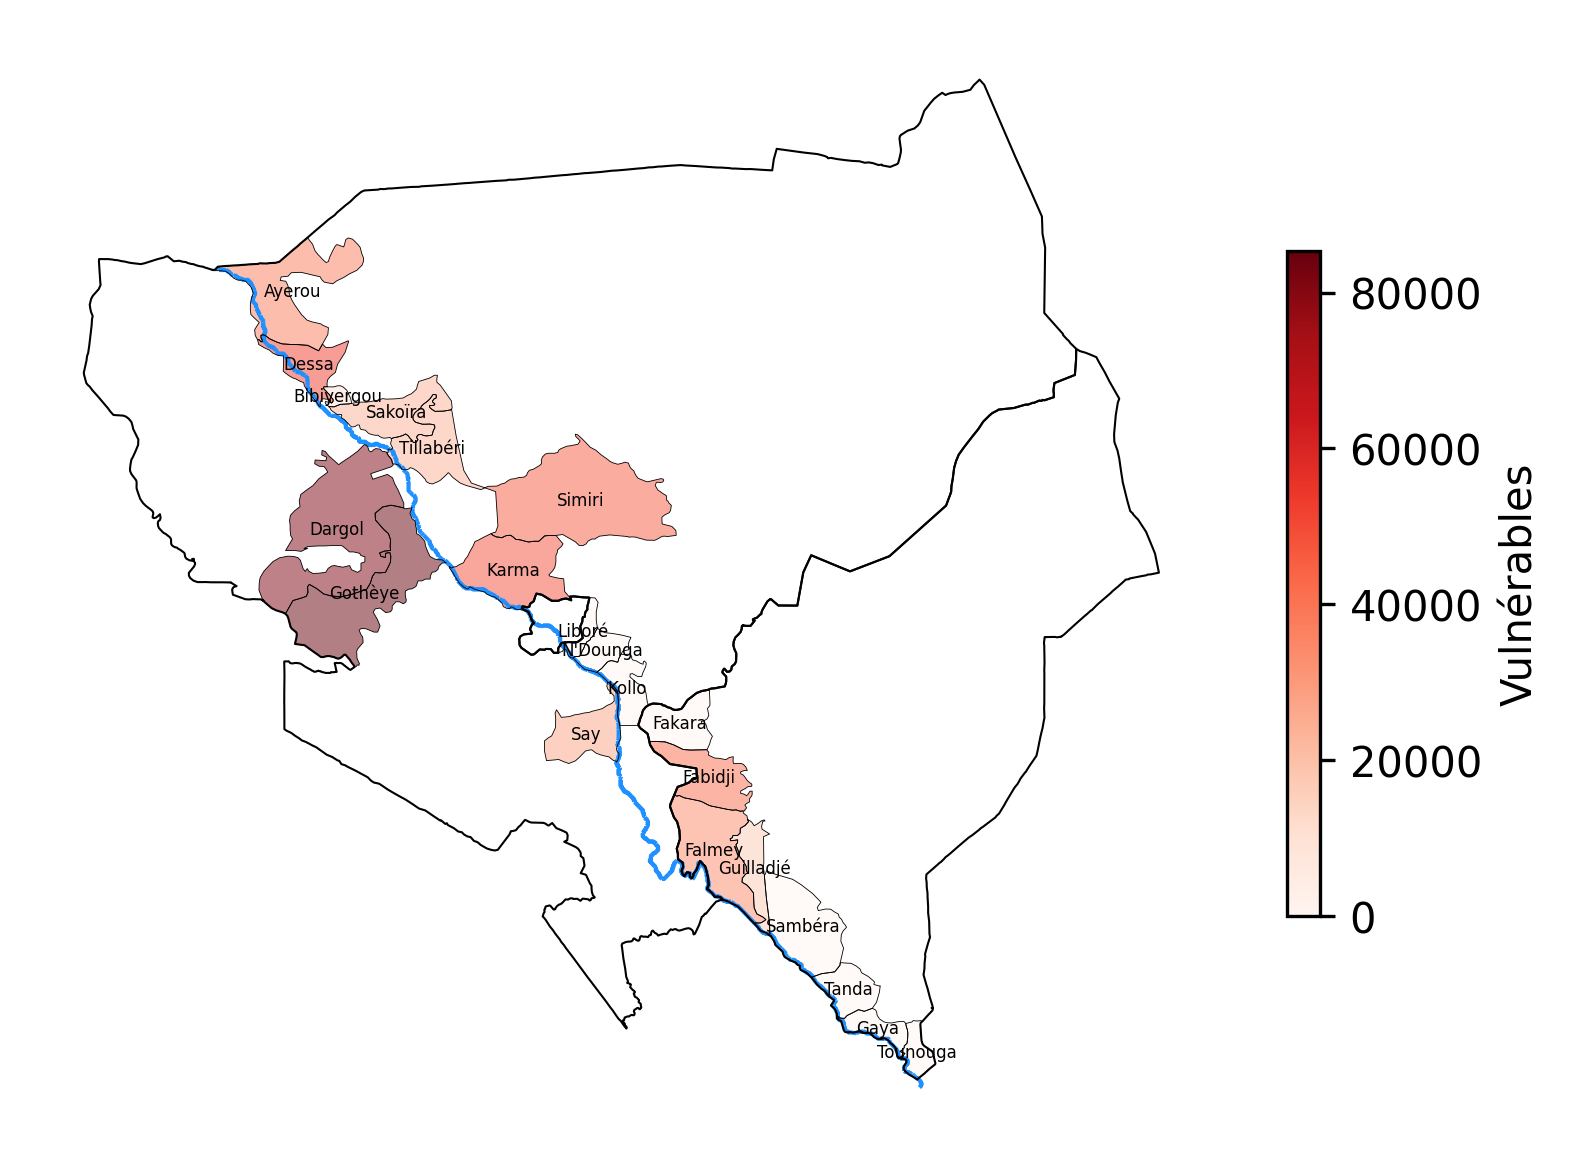

In [9]:
gdf_plot = adm3.merge(df)

plot_col = "Vulnérables"

fig, ax = plt.subplots(dpi=300)
river_aoi.plot(ax=ax, color="dodgerblue", linewidth=1)
adm1.boundary.plot(ax=ax, linewidth=0.5, color="k")
gdf_plot.plot(
    ax=ax,
    column=plot_col,
    cmap="Reds",
    alpha=0.5,
    legend=True,
    legend_kwds={
        "label": plot_col,
        "shrink": 0.6,
    },
)
gdf_plot.boundary.plot(ax=ax, linewidth=0.2, color="k")

for idx, row in gdf_plot.iterrows():
    plt.annotate(
        text=row["Commune"],
        xy=(row["geometry"].centroid.x, row["geometry"].centroid.y),
        horizontalalignment="center",
        verticalalignment="center",
        fontsize=4,
    )
ax.axis("off")

In [29]:
gdf_plot

,ADM3_FR,ADM3_PCODE,ADM2_FR,ADM2_PCODE,ADM1_FR,ADM1_PCODE,ADM0_FR,ADM0_PCODE,DATE,VALIDON,VALIDTO,geometry
59,Gaya,NE003006003,Gaya,NE003006,Dosso,NE003,Niger (the),NE,2023-06-21,2023-07-25,NaN,"POLYGON ((3.52631 11.78344, 3.52267 11.79219, ..."
60,Tanda,NE003006004,Gaya,NE003006,Dosso,NE003,Niger (the),NE,2023-06-21,2023-07-25,NaN,"POLYGON ((3.27249 11.96256, 3.26880 11.97293, ..."
61,Tounouga,NE003006005,Gaya,NE003006,Dosso,NE003,Niger (the),NE,2023-06-21,2023-07-25,NaN,"POLYGON ((3.61767 11.91689, 3.62123 11.86859, ..."
177,Karma,NE006008004,Kollo,NE006008,Tillabéri,NE006,Niger (the),NE,2023-06-21,2023-07-25,NaN,"POLYGON ((1.89050 13.87128, 1.90088 13.87628, ..."
181,Liboré,NE006008008,Kollo,NE006008,Tillabéri,NE006,Niger (the),NE,2023-06-21,2023-07-25,NaN,"POLYGON ((2.28247 13.50470, 2.27710 13.49487, ..."
182,N'Dounga,NE006008009,Kollo,NE006008,Tillabéri,NE006,Niger (the),NE,2023-06-21,2023-07-25,NaN,"POLYGON ((2.37250 13.38452, 2.37207 13.37848, ..."


(-0.05552903579999999, 4.8236206858, 11.462306522549298, 15.912396359783367)

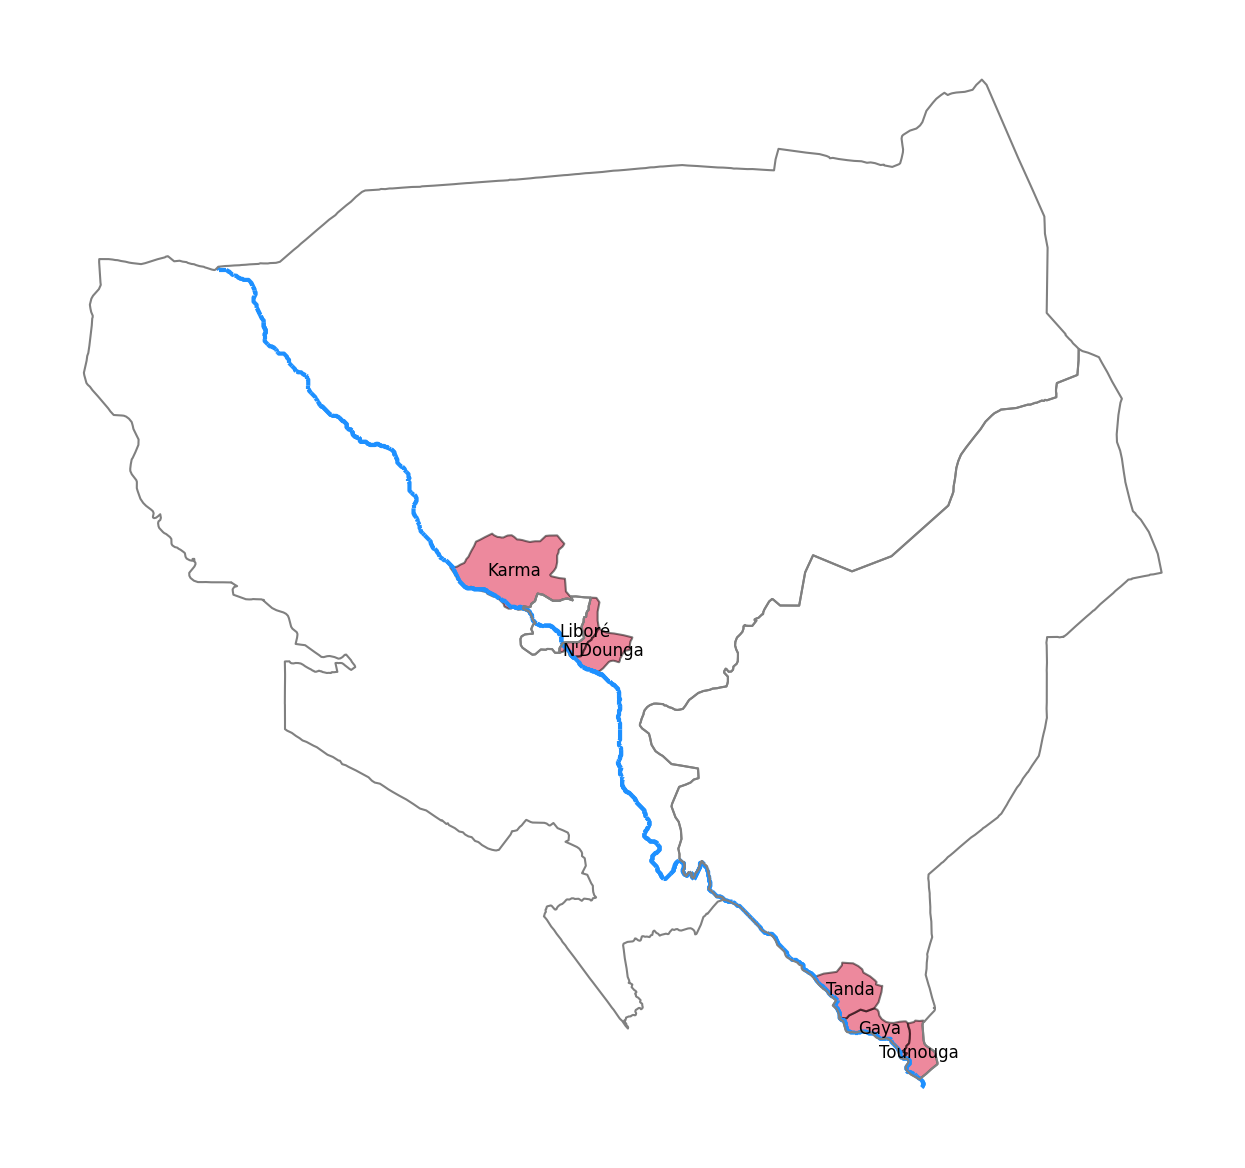

In [31]:
gdf_plot = adm3[adm3["ADM3_PCODE"].isin(ADM3_AOI_PCODES)]

fig, ax = plt.subplots(dpi=300)
river_aoi.plot(ax=ax, color="dodgerblue", linewidth=1)
adm1.boundary.plot(ax=ax, linewidth=0.5, color="grey")
gdf_plot.plot(
    ax=ax, facecolor="crimson", edgecolor="black", linewidth=0.5, alpha=0.5
)

for idx, row in gdf_plot.iterrows():
    plt.annotate(
        text=row["ADM3_FR"],
        xy=(row["geometry"].centroid.x, row["geometry"].centroid.y),
        horizontalalignment="center",
        verticalalignment="center",
        fontsize=4,
    )

ax.axis("off")